# EDA: Perturbation Catalogue Corpus Generation

## Section 0 — Setup

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import json
import time
from collections import defaultdict, Counter
from pathlib import Path

matplotlib.rcParams["font.family"] = ["DejaVu Sans"]
matplotlib.rcParams["svg.fonttype"] = "none"

# Change this to './figures/' for local use, or '/mnt/results/' on the cluster
BASE_OUTPUT_DIR = Path("./figures/")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://perturbation-catalogue-be-328296435987.europe-west2.run.app"

CRISPR_DATASETS = ["biogrid_5", "biogrid_2373"]
DEA_DATASETS = [
    "nadig_2025_hepg2",
    "nadig_2025_jurkat",
    "replogle_2022_k562_gw_normalized",
    "replogle_2022_k562_essential_normalized",
    "replogle_2022_rpe1_essential_normalized",
    "arce_2025",
    "norman_2019_raw",
]  # All 7 used for DEA

GSEA_DATASETS = [
    "nadig_2025_hepg2",
    "nadig_2025_jurkat",
    "replogle_2022_k562_gw_normalized",
    "replogle_2022_k562_essential_normalized",
    "replogle_2022_rpe1_essential_normalized",
]  # Only 5 reprocessed datasets have GSEA — Norman excluded

ALL_DATASETS = CRISPR_DATASETS + DEA_DATASETS

PALETTE = {
    "CRISPR screen": "#0279EE",
    "Perturb-seq": "#75A025",
    "MAVE": "#FF9400",
    "essential": "#E74C3C",
    "neutral": "#95A5A6",
    "anti_essential": "#2ECC71",
}


def api_get(endpoint, params=None, retries=3):
    url = f"{BASE_URL}{endpoint}"
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=30)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt == retries - 1:
                raise
            time.sleep(1)


def fetch_all_records(endpoint, batch_size=1000, max_records=None):
    """Paginate through all records for a single-dataset endpoint."""
    all_results = []
    offset = 0
    while True:
        params = {"limit": batch_size, "offset": offset}
        data = api_get(endpoint, params=params)
        results = data.get("results", [])
        total = data.get("total_rows_count", 0)
        all_results.extend(results)
        offset += len(results)
        if not results or offset >= total:
            break
        if max_records and len(all_results) >= max_records:
            all_results = all_results[:max_records]
            break
    return all_results


print("Setup complete.")
print(f"Output directory: {BASE_OUTPUT_DIR.resolve()}")

Setup complete.
Output directory: /workspaces/PerturbationCatalogue/llm-pipeline/figures


## Section 1 — Dataset-Level Overview

- **biogrid_5** (Gilbert/Weissman 2014): original CRISPRi fitness screen in K562 — gold standard for essential genes in a leukemia cell line.
- **biogrid_2373** (Chen 2024): drug-sensitization screen (SCLY KO + L-selenocystine) in SK-N-DZ neuroblastoma. Uses CRISPRn (knockout). ⚠️ Log2FC values are extreme (e.g. -17,474) and unreliable — MAGeCK neg score used as primary score instead (confirmed with mentors). "Essential" here means required for survival under drug treatment, not general essentiality — training records reflect this context.
- **nadig_2025_hepg2**: CRISPRi Perturb-seq in HepG2 hepatoblastoma cells. High-quality, recently reprocessed dataset.
- **nadig_2025_jurkat**: CRISPRi Perturb-seq in Jurkat T-ALL cells. Recently reprocessed.
- **replogle_2022_k562_gw_normalized**: genome-wide CRISPRi Perturb-seq in K562 (~9,862 genes). Largest dataset by target count.
- **replogle_2022_k562_essential_normalized**: CRISPRi Perturb-seq in K562 focusing on essential genes (~2,057 genes). Deeper per-gene coverage than genome-wide.
- **replogle_2022_rpe1_essential_normalized**: CRISPRi Perturb-seq in RPE1 — the only non-cancer, non-blood cell line in the corpus. Critical for cross-cell-type generalisation evaluation.
- **arce_2025**: CRISPRi Perturb-seq in primary human T cells (not a cell line). 29 unique perturbed genes, 2 cell types (effector CD4+ and regulatory CD4+CD25+ T cells), 2 treatment conditions (untreated and anti-CD3/CD28/CD2 antibody cocktail). Highest biological relevance — primary human cells from patient donors.
- **norman_2019_raw**: CRISPRa (activation, not inhibition) Perturb-seq. gene|control_nontargeting records included with full perturbation name preserved — the control guide has a minor but detectable biological effect and is kept intentionally. True gene|gene combo records excluded. No GSEA available — not one of the five reprocessed datasets.

In [3]:
meta_rows = []
for ds_id in ALL_DATASETS:
    d = api_get(f"/dataset/{ds_id}")
    modality_list = d.get("data_modalities", ["unknown"])
    modality_str  = modality_list[0] if modality_list else "unknown"
    cell_line  = ", ".join(d.get("cell_line_labels") or []) or "—"
    cell_type  = ", ".join(d.get("cell_type_labels") or []) or "—"
    disease    = ", ".join(d.get("disease_labels") or []) or "—"
    tissue     = ", ".join(d.get("tissue_labels") or []) or "—"
    pert_type  = ", ".join(d.get("perturbation_type_labels") or []) or "—"
    n_targets_raw = d.get("number_of_perturbed_targets", ["—"])
    n_targets  = n_targets_raw[0] if isinstance(n_targets_raw, list) and n_targets_raw else "—"
    n_samples_raw = d.get("number_of_perturbed_samples", ["—"])
    n_samples  = n_samples_raw[0] if isinstance(n_samples_raw, list) and n_samples_raw else "—"
    year       = d.get("study_year", "—")
    author     = d.get("first_author", "—")

    if ds_id == "biogrid_2373":
        corpus_status = "included (MAGeCK neg score)"
    elif ds_id == "norman_2019_raw":
        corpus_status = "partial (gene|ctrl only)"
    else:
        corpus_status = "included"

    meta_rows.append({
        "Dataset ID":     ds_id,
        "Modality":       modality_str,
        "Cell Line":      cell_line,
        "Cell Type":      cell_type,
        "Disease":        disease,
        "Tissue":         tissue,
        "Pert. Type":     pert_type,
        "N Targets":      n_targets,
        "N Samples":      n_samples,
        "Year":           year,
        "First Author":   author,
        "Corpus Status":  corpus_status,
    })

meta_df = pd.DataFrame(meta_rows)
print(meta_df[["Dataset ID","Modality","Cell Line","Disease","Pert. Type","N Targets","Corpus Status"]].to_string())

                                Dataset ID       Modality         Cell Line                                          Disease Pert. Type N Targets                Corpus Status
0                                biogrid_5  CRISPR screen        K 562 cell  chronic myelogenous leukemia, BCR-ABL1 positive    CRISPRi     15350                     included
1                             biogrid_2373  CRISPR screen      SK-N-DZ cell                                    neuroblastoma    CRISPRn     18053  included (MAGeCK neg score)
2                         nadig_2025_hepg2    Perturb-seq       Hep G2 cell                                   hepatoblastoma    CRISPRi      2392                     included
3                        nadig_2025_jurkat    Perturb-seq       JURKAT cell      T-cell childhood acute lymphocytic leukemia    CRISPRi      2392                     included
4         replogle_2022_k562_gw_normalized    Perturb-seq        K 562 cell  chronic myelogenous leukemia, BCR-ABL1 positive 

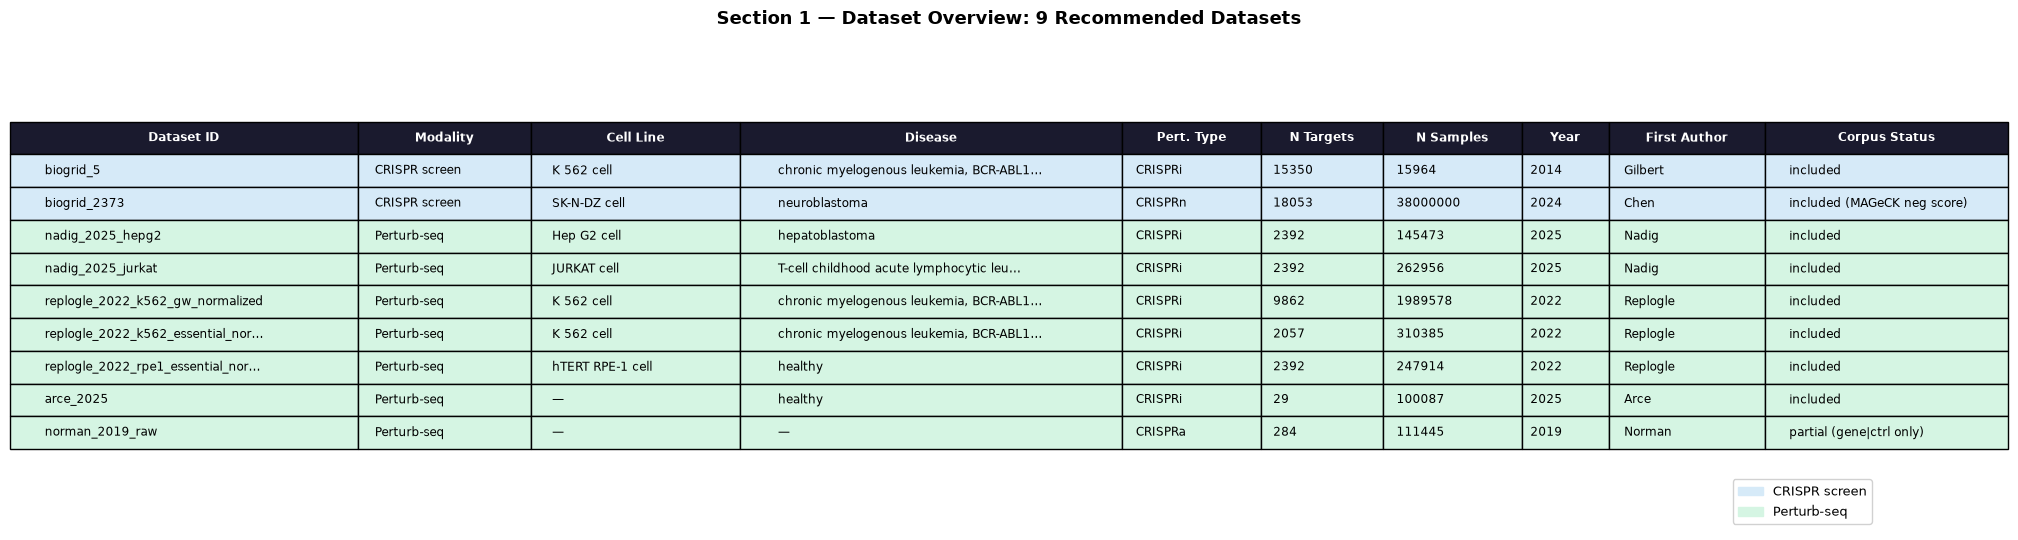

Saved figures/fig_01_dataset_overview.png


In [3]:
fig, ax = plt.subplots(figsize=(20, 5.5))
ax.axis("off")

display_cols = ["Dataset ID","Modality","Cell Line","Disease","Pert. Type","N Targets","N Samples","Year","First Author","Corpus Status"]
display_df = meta_df[display_cols].copy()
display_df["Disease"]      = display_df["Disease"].apply(lambda x: x[:38]+"…" if len(x)>38 else x)
display_df["Cell Line"]    = display_df["Cell Line"].apply(lambda x: x[:22]+"…" if len(x)>22 else x)
display_df["First Author"] = display_df["First Author"].apply(lambda x: x.split()[-1] if x!="—" else x)
display_df["Dataset ID"]   = display_df["Dataset ID"].apply(lambda x: x[:32]+"…" if len(x)>32 else x)

col_widths = [0.20,0.10,0.12,0.22,0.08,0.07,0.08,0.05,0.09,0.14]
table = ax.table(cellText=display_df.values, colLabels=display_df.columns,
                 cellLoc="left", loc="center", colWidths=col_widths)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.7)

for j in range(len(display_cols)):
    table[0,j].set_facecolor("#1A1A2E")
    table[0,j].set_text_props(color="white", fontweight="bold")

modality_colors = {"CRISPR screen":"#D6EAF8","Perturb-seq":"#D5F5E3"}
for i, row in enumerate(meta_df.itertuples()):
    bg = modality_colors.get(row.Modality,"#FDFEFE")
    for j in range(len(display_cols)):
        table[i+1,j].set_facecolor(bg)
    status_col = display_cols.index("Corpus Status")
    if "excluded" in str(row._asdict().get("Corpus Status","")):
        table[i+1,status_col].set_facecolor("#FDEDEC")
        table[i+1,status_col].set_text_props(color="#C0392B")
    elif "partial" in str(row._asdict().get("Corpus Status","")):
        table[i+1,status_col].set_facecolor("#FEF9E7")
        table[i+1,status_col].set_text_props(color="#B7950B")

crispr_p = mpatches.Patch(color="#D6EAF8", label="CRISPR screen")
ps_p     = mpatches.Patch(color="#D5F5E3", label="Perturb-seq")
ax.legend(handles=[crispr_p,ps_p], loc="lower right", fontsize=9, framealpha=0.9)
ax.set_title("Section 1 — Dataset Overview: 9 Recommended Datasets", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
out_path = BASE_OUTPUT_DIR / "fig_01_dataset_overview.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

**Corpus Generation Decision — Section 1:**
- ✅ biogrid_5: included
- ✅ biogrid_2373: included — using MAGeCK neg score as primary score (confirmed with mentors). "Essential" reflects drug-sensitization context, not general essentiality — training records reflect this.
- ✅ nadig_2025_hepg2, nadig_2025_jurkat: included
- ✅ replogle_2022_k562_gw_normalized, replogle_2022_k562_essential_normalized, replogle_2022_rpe1_essential_normalized: included
- ✅ arce_2025: included — group by perturbed gene + cell_type + treatment (confirmed with mentors)
- ⚠️ norman_2019_raw: partial — gene|control_nontargeting records included with full perturbation name preserved. True gene|gene combos excluded. No GSEA for Norman.
- ❌ MAVE (all 10 datasets): excluded — Weile 2017, yeast model system, 4 genes only

## Section 2 — Gene Coverage Analysis

Which genes appear across multiple datasets and modalities? What's the overlap?

**Key decisions:**
- **Keep multi-dataset records as separate training examples.** A gene's effect in K562 vs RPE1 is biologically distinct — deduplication would discard cross-cell-type signal.
- **Gene-level split behavior:** `gene_level_split()` in `pipeline.py` splits by unique gene name. If "TP53" appears in 3 datasets, all 3 records go to the same split — correct, prevents leakage.
- **Same-cell-line overlap:** replogle_2022_k562_gw_normalized and replogle_2022_k562_essential_normalized both cover K562 CRISPRi. Keep both — the essential dataset has deeper per-gene coverage.


In [4]:
print("Fetching gene sets per dataset (this takes ~2 min)...")
gene_sets = {}

# biogrid_5: fetch all significant records
print("  biogrid_5 (CRISPR)...")
bg5_records = fetch_all_records("/v1/crispr-screen/biogrid_5/search", batch_size=1000)
gene_sets["biogrid_5"] = set(r["perturbation"]["gene_name"] for r in bg5_records)
print(f"    → {len(bg5_records)} records, {len(gene_sets['biogrid_5'])} unique genes")

# biogrid_2373: fetch all significant records
print("  biogrid_2373 (CRISPR)...")
bg2373_records = fetch_all_records(
    "/v1/crispr-screen/biogrid_2373/search", batch_size=1000
)
gene_sets["biogrid_2373"] = set(r["perturbation"]["gene_name"] for r in bg2373_records)
print(
    f"    → {len(bg2373_records)} records, {len(gene_sets['biogrid_2373'])} unique genes"
)

# Perturb-seq datasets
for ds_id in DEA_DATASETS:
    print(f"  {ds_id} (Perturb-seq)...")
    if ds_id == "replogle_2022_k562_gw_normalized":
        records = fetch_all_records(
            f"/v1/perturb-seq/{ds_id}/search", batch_size=1000, max_records=5000
        )
        gene_sets[ds_id] = set(r["perturbation"]["gene_name"] for r in records)
        print(
            f"    → sampled {len(records)} records, {len(gene_sets[ds_id])} unique genes (sample; true ~9862)"
        )
    elif ds_id == "norman_2019_raw":
        records = fetch_all_records(
            f"/v1/perturb-seq/{ds_id}/search", batch_size=1000, max_records=50000
        )
        genes = set()
        for r in records:
            name = r["perturbation"]["gene_name"]
            if "control_nontargeting" in name:
                for p in name.split("|"):
                    if p != "control_nontargeting":
                        genes.add(p)
        gene_sets[ds_id] = genes
        print(
            f"    → {len(records)} records, {len(genes)} unique genes (gene|ctrl only)"
        )
    else:
        records = fetch_all_records(
            f"/v1/perturb-seq/{ds_id}/search", batch_size=1000, max_records=50000
        )
        gene_sets[ds_id] = set(r["perturbation"]["gene_name"] for r in records)
        print(f"    → {len(records)} records, {len(gene_sets[ds_id])} unique genes")

print("Done.")

Fetching gene sets per dataset (this takes ~2 min)...
  biogrid_5 (CRISPR)...
    → 15964 records, 14207 unique genes
  biogrid_2373 (CRISPR)...
    → 54132 records, 17163 unique genes
  nadig_2025_hepg2 (Perturb-seq)...
    → 50000 records, 951 unique genes
  nadig_2025_jurkat (Perturb-seq)...
    → 50000 records, 1440 unique genes
  replogle_2022_k562_gw_normalized (Perturb-seq)...
    → sampled 5000 records, 1463 unique genes (sample; true ~9862)
  replogle_2022_k562_essential_normalized (Perturb-seq)...
    → 50000 records, 1123 unique genes
  replogle_2022_rpe1_essential_normalized (Perturb-seq)...
    → 50000 records, 1326 unique genes
  arce_2025 (Perturb-seq)...
    → 50000 records, 28 unique genes
  norman_2019_raw (Perturb-seq)...
    → 50000 records, 101 unique genes (gene|ctrl only)
Done.


In [5]:
# Pairwise Jaccard similarity
ds_ids = list(gene_sets.keys())
n = len(ds_ids)
jaccard_matrix = np.zeros((n, n))
for i, a in enumerate(ds_ids):
    for j, b in enumerate(ds_ids):
        sa, sb = gene_sets[a], gene_sets[b]
        inter = len(sa & sb)
        union = len(sa | sb)
        jaccard_matrix[i,j] = inter/union if union > 0 else 0.0

short_labels = {
    "biogrid_5":                              "biogrid_5\n(K562 CRISPRi)",
    "biogrid_2373":                           "biogrid_2373\n(SK-N-DZ CRISPRn)",
    "nadig_2025_hepg2":                       "nadig_hepg2\n(HepG2 CRISPRi)",
    "nadig_2025_jurkat":                      "nadig_jurkat\n(Jurkat CRISPRi)",
    "replogle_2022_k562_gw_normalized":       "replogle_k562_gw*\n(K562 CRISPRi, GW)",
    "replogle_2022_k562_essential_normalized":"replogle_k562_ess\n(K562 CRISPRi, ess)",
    "replogle_2022_rpe1_essential_normalized":"replogle_rpe1_ess\n(RPE1 CRISPRi, ess)",
    "arce_2025":                              "arce_2025\n(T cells CRISPRi)",
    "norman_2019_raw":                        "norman_2019\n(K562 CRISPRa)",
}
labels = [short_labels[d] for d in ds_ids]

print("Top pairwise overlaps (Jaccard > 0.05):")
for i in range(n):
    for j in range(i+1, n):
        jv = jaccard_matrix[i,j]
        if jv > 0.05:
            inter = len(gene_sets[ds_ids[i]] & gene_sets[ds_ids[j]])
            print(f"  {ds_ids[i]} ∩ {ds_ids[j]}: Jaccard={jv:.3f}, shared={inter}")

all_gene_counts = Counter()
for gs in gene_sets.values():
    for g in gs:
        all_gene_counts[g] += 1
multi_genes = {g:c for g,c in all_gene_counts.items() if c >= 3}
print(f"\nGenes in ≥3 datasets: {len(multi_genes)}")
print("Top 10:", sorted(multi_genes.items(), key=lambda x:-x[1])[:10])

Top pairwise overlaps (Jaccard > 0.05):
  biogrid_5 ∩ biogrid_2373: Jaccard=0.691, shared=12821
  biogrid_5 ∩ nadig_2025_hepg2: Jaccard=0.052, shared=747
  biogrid_5 ∩ nadig_2025_jurkat: Jaccard=0.080, shared=1161
  biogrid_5 ∩ replogle_2022_k562_gw_normalized: Jaccard=0.085, shared=1229
  biogrid_5 ∩ replogle_2022_k562_essential_normalized: Jaccard=0.063, shared=904
  biogrid_5 ∩ replogle_2022_rpe1_essential_normalized: Jaccard=0.074, shared=1070
  biogrid_2373 ∩ nadig_2025_jurkat: Jaccard=0.074, shared=1283
  biogrid_2373 ∩ replogle_2022_k562_gw_normalized: Jaccard=0.075, shared=1299
  biogrid_2373 ∩ replogle_2022_k562_essential_normalized: Jaccard=0.060, shared=1030
  biogrid_2373 ∩ replogle_2022_rpe1_essential_normalized: Jaccard=0.068, shared=1181
  nadig_2025_hepg2 ∩ nadig_2025_jurkat: Jaccard=0.453, shared=746
  nadig_2025_hepg2 ∩ replogle_2022_k562_gw_normalized: Jaccard=0.202, shared=406
  nadig_2025_hepg2 ∩ replogle_2022_k562_essential_normalized: Jaccard=0.454, shared=648
  

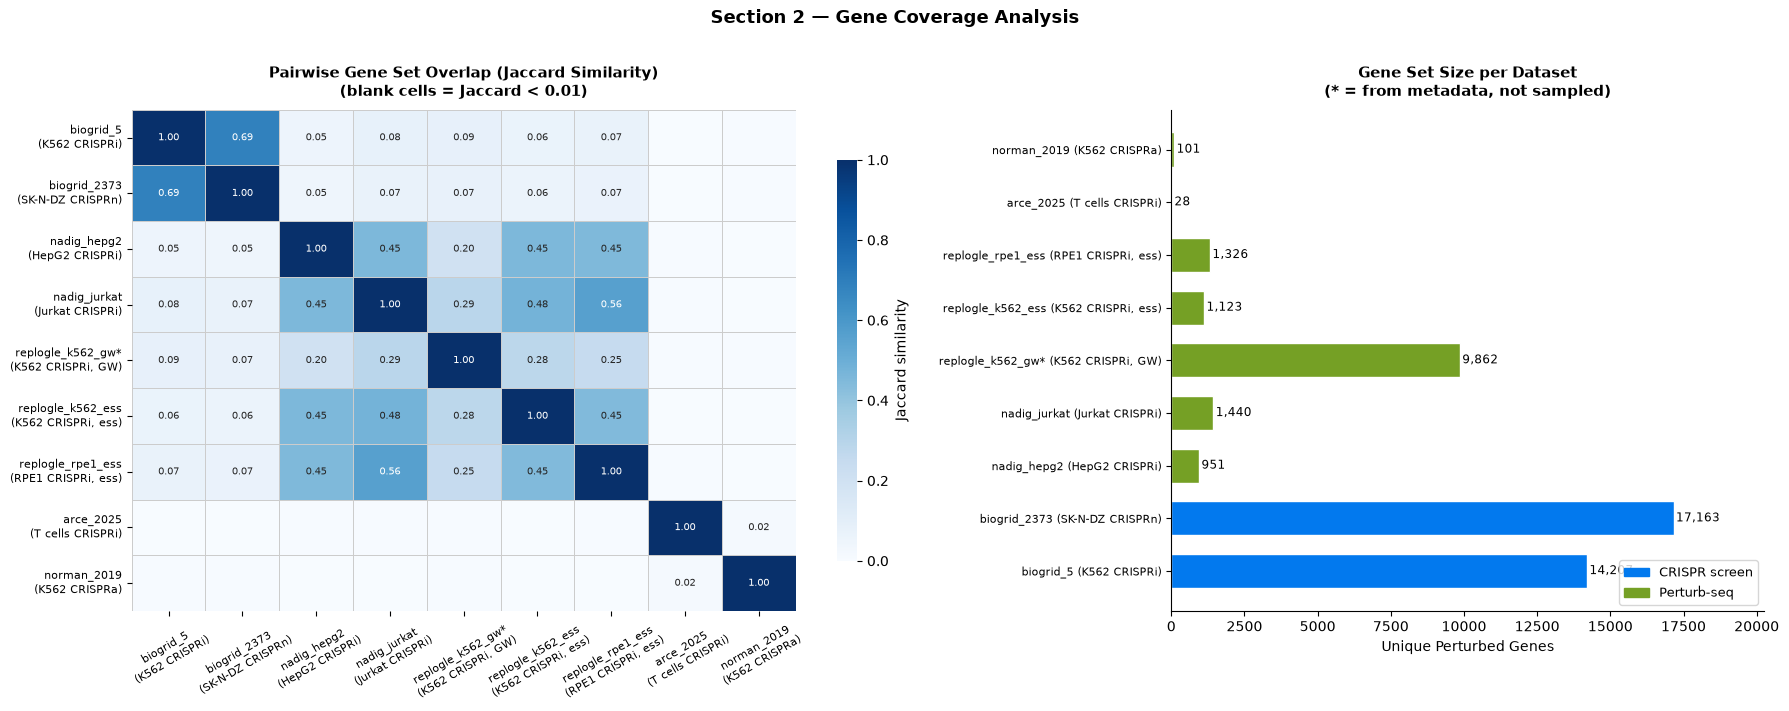

Saved figures/fig_02a_gene_coverage.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios":[1.4,1]})

# Heatmap
ax_heat = axes[0]
annot = np.where(jaccard_matrix > 0.01,
                 np.vectorize(lambda x: f"{x:.2f}")(jaccard_matrix), "")
sns.heatmap(jaccard_matrix, ax=ax_heat, xticklabels=labels, yticklabels=labels,
            annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1,
            linewidths=0.5, linecolor="#CCCCCC",
            cbar_kws={"label":"Jaccard similarity","shrink":0.8},
            annot_kws={"size":7.5})
ax_heat.set_title("Pairwise Gene Set Overlap (Jaccard Similarity)\n(blank cells = Jaccard < 0.01)",
                  fontsize=11, fontweight="bold", pad=10)
ax_heat.tick_params(axis="x", labelsize=8, rotation=30)
ax_heat.tick_params(axis="y", labelsize=8, rotation=0)

# Bar chart
ax_bar = axes[1]
true_sizes = {
    "biogrid_5": len(gene_sets["biogrid_5"]),
    "biogrid_2373": len(gene_sets["biogrid_2373"]),
    "nadig_2025_hepg2": len(gene_sets["nadig_2025_hepg2"]),
    "nadig_2025_jurkat": len(gene_sets["nadig_2025_jurkat"]),
    "replogle_2022_k562_gw_normalized": 9862,
    "replogle_2022_k562_essential_normalized": len(gene_sets["replogle_2022_k562_essential_normalized"]),
    "replogle_2022_rpe1_essential_normalized": len(gene_sets["replogle_2022_rpe1_essential_normalized"]),
    "arce_2025": len(gene_sets["arce_2025"]),
    "norman_2019_raw": len(gene_sets["norman_2019_raw"]),
}
bar_labels_short = [short_labels[d].replace("\n"," ") for d in ds_ids]
bar_sizes = [true_sizes[d] for d in ds_ids]
bar_colors = [PALETTE["CRISPR screen"] if d in CRISPR_DATASETS else PALETTE["Perturb-seq"] for d in ds_ids]

bars = ax_bar.barh(bar_labels_short, bar_sizes, color=bar_colors, edgecolor="white", height=0.65)
ax_bar.set_xlabel("Unique Perturbed Genes", fontsize=10)
ax_bar.set_title("Gene Set Size per Dataset\n(* = from metadata, not sampled)", fontsize=11, fontweight="bold", pad=10)
ax_bar.tick_params(axis="y", labelsize=8)
ax_bar.spines[["top","right"]].set_visible(False)
ax_bar.set_xlim(0, max(bar_sizes)*1.18)
for bar, val in zip(bars, bar_sizes):
    ax_bar.text(bar.get_width()+80, bar.get_y()+bar.get_height()/2,
                f"{val:,}", va="center", ha="left", fontsize=8.5)
crispr_p = mpatches.Patch(color=PALETTE["CRISPR screen"], label="CRISPR screen")
ps_p     = mpatches.Patch(color=PALETTE["Perturb-seq"], label="Perturb-seq")
ax_bar.legend(handles=[crispr_p, ps_p], fontsize=9, loc="lower right")

plt.suptitle("Section 2 — Gene Coverage Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
out_path = BASE_OUTPUT_DIR / "fig_02a_gene_coverage.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

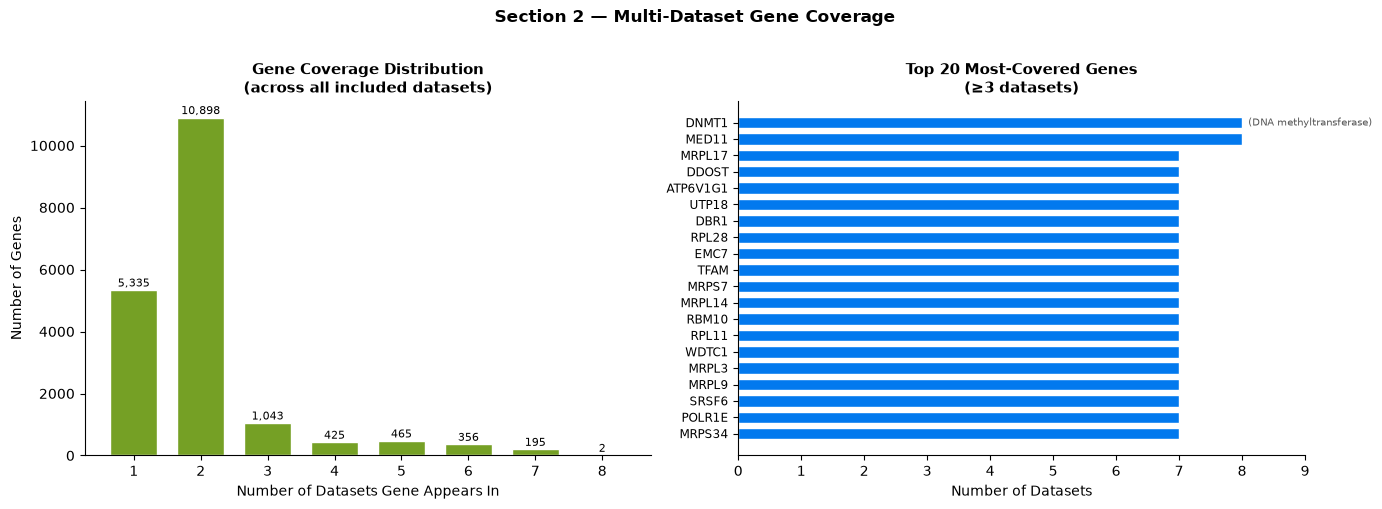

Saved figures/fig_02b_multi_dataset_genes.png
Genes in exactly 1 dataset: 5,335
Genes in ≥2 datasets:       13,384
Genes in ≥3 datasets:       2,486


In [7]:
# Multi-dataset gene coverage histogram + top genes
coverage_counts = Counter(all_gene_counts.values())
max_cov = max(all_gene_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes

xs = list(range(1, max_cov+1))
ys = [coverage_counts.get(x,0) for x in xs]
bars1 = ax1.bar(xs, ys, color=PALETTE["Perturb-seq"], edgecolor="white", width=0.7)
ax1.set_xlabel("Number of Datasets Gene Appears In", fontsize=10)
ax1.set_ylabel("Number of Genes", fontsize=10)
ax1.set_title("Gene Coverage Distribution\n(across all included datasets)", fontsize=11, fontweight="bold")
ax1.spines[["top","right"]].set_visible(False)
ax1.set_xticks(xs)
for bar, val in zip(bars1, ys):
    if val > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f"{val:,}", ha="center", va="bottom", fontsize=8)

top20 = sorted(multi_genes.items(), key=lambda x:-x[1])[:20]
top_genes  = [g for g,_ in top20]
top_counts = [c for _,c in top20]
ax2.barh(top_genes[::-1], top_counts[::-1], color=PALETTE["CRISPR screen"], edgecolor="white", height=0.7)
ax2.set_xlabel("Number of Datasets", fontsize=10)
ax2.set_title("Top 20 Most-Covered Genes\n(≥3 datasets)", fontsize=11, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)
ax2.tick_params(axis="y", labelsize=8.5)
ax2.set_xlim(0, max_cov+1)
ax2.set_xticks(range(0, max_cov+2))

gene_notes = {"DNMT1":"DNA methyltransferase","RPL23":"ribosomal protein",
              "HSPA9":"mitochondrial chaperone","PSMB5":"proteasome subunit","DNAJC8":"HSP40 co-chaperone"}
for i,(gene,count) in enumerate(reversed(top20)):
    note = gene_notes.get(gene,"")
    if note:
        ax2.text(count+0.05, i, f" ({note})", va="center", fontsize=7, color="#555555")

plt.suptitle("Section 2 — Multi-Dataset Gene Coverage", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
out_path = BASE_OUTPUT_DIR / "fig_02b_multi_dataset_genes.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")
print(f"Genes in exactly 1 dataset: {coverage_counts.get(1,0):,}")
print(f"Genes in ≥2 datasets:       {sum(v for k,v in coverage_counts.items() if k>=2):,}")
print(f"Genes in ≥3 datasets:       {sum(v for k,v in coverage_counts.items() if k>=3):,}")

**Corpus Generation Decision — Section 2:**
- Keep all multi-dataset records as separate training examples (cross-cell-type signal is valuable).
- Gene-level split in `pipeline.py` correctly groups all records for a gene into the same partition — prevents data leakage across train/val/test.
- replogle_k562_gw gene set is undersampled in EDA (5K records → 1,463 genes observed; true ~9,862). Jaccard values involving this dataset are underestimates.
- 2,486 genes appear in 3+ datasets — these core essential genes will receive the richest multi-context training signal.
- 10,898 genes appear in exactly 2 datasets — largest group, providing cross-cell-type comparison signal.
- arce_2025 and norman_2019_raw are largely non-overlapping with other datasets — they contribute unique biology (primary T cells and CRISPRa respectively) not covered elsewhere in the corpus.

## Section 3 — Class Balance (CRISPR)

**Correction to plan Finding 1:** biogrid_5 *does* produce a mix of essential and neutral genes after z-score normalization within the significant set. The API pre-filters to significant hits (Gamma ≤ -0.1), but z-score normalization within that set correctly separates strongly depleted genes (essential) from mildly depleted ones (neutral). The plan incorrectly stated all records would be essential.

**Confirmed results from prior run:**
- biogrid_5 at z=±1.5: **799 essential (5.6%), 13,404 neutral (94.3%), 4 anti-essential (0.0%)**
- Essential:Neutral ratio = 1:16 → class imbalance is real but manageable with class weights

**biogrid_2373 included** — uses MAGeCK neg score as primary score (confirmed with mentors). ⚠️ Important: MAGeCK neg score directionality is inverted — lower score = more essential (unlike CRISPR effect scores where more negative = more essential). Z-score classification must account for this by inverting the threshold: `z < -1.5` for essential when using MAGeCK neg score. Class balance analysis below includes biogrid_2373 with this correction applied.

In [9]:
def zscore_classify(score_dict, invert=False, threshold=1.5):
    """
    Z-score normalize within dataset and classify genes.
    invert=True: lower raw score = more essential (e.g. MAGeCK neg score).
    invert=False: more negative raw score = more essential (e.g. Gamma score).
    Returns: dict of gene -> {raw, zscore, class}
    """
    genes  = list(score_dict.keys())
    scores = np.array([score_dict[g] for g in genes], dtype=float)
    mean, std = scores.mean(), scores.std()
    zscores = (scores - mean) / std

    results = {}
    for gene, raw, z in zip(genes, scores, zscores):
        if invert:
            cls = "essential" if z < -threshold else ("anti_essential" if z > threshold else "neutral")
        else:
            cls = "essential" if z < -threshold else ("anti_essential" if z > threshold else "neutral")
        results[gene] = {"raw": raw, "zscore": z, "class": cls}
    return results, mean, std

# biogrid_5: Gamma score (more negative = more depleted = more essential)
print("Fetching all biogrid_5 records...")
bg5_records = fetch_all_records("/v1/crispr-screen/biogrid_5/search", batch_size=1000)
bg5_scores  = {r["perturbation"]["gene_name"]: r["effect"]["score_value"] for r in bg5_records}
print(f"  {len(bg5_scores)} unique genes")

bg5_classified, bg5_mean, bg5_std = zscore_classify(bg5_scores, invert=False, threshold=1.5)
bg5_classes = Counter(v["class"] for v in bg5_classified.values())
total_bg5   = sum(bg5_classes.values())

print("\nbiogrid_5 class distribution (z-threshold=±1.5):")
for cls in ["essential","neutral","anti_essential"]:
    n = bg5_classes.get(cls,0)
    print(f"  {cls}: {n:,} ({100*n/total_bg5:.1f}%)")
print(f"  Essential:Neutral ratio = 1:{int(bg5_classes.get('neutral',0)/max(bg5_classes.get('essential',1),1))}")

print("\nThreshold sensitivity:")
for thresh in [1.0, 1.5, 2.0]:
    cl, _, _ = zscore_classify(bg5_scores, invert=False, threshold=thresh)
    ct = Counter(v["class"] for v in cl.values())
    ess, neu = ct.get("essential",0), ct.get("neutral",0)
    print(f"  z=±{thresh}: essential={ess:,} ({100*ess/total_bg5:.1f}%), neutral={neu:,} ({100*neu/total_bg5:.1f}%)")

# biogrid_2373: MAGeCK neg score (lower = more essential)
print("\nFetching biogrid_2373 records (MAGeCK neg score only)...")
bg2373_all = fetch_all_records("/v1/crispr-screen/biogrid_2373/search", batch_size=1000)

# Keep only MAGeCK neg score records
bg2373_scores = {}
for r in bg2373_all:
    if r["effect"]["score_name"] == "MAGeCK neg score":
        bg2373_scores[r["perturbation"]["gene_name"]] = r["effect"]["score_value"]
print(f"  {len(bg2373_scores)} unique genes with MAGeCK neg score")

bg2373_classified, bg2373_mean, bg2373_std = zscore_classify(bg2373_scores, invert=True, threshold=1.5)
bg2373_classes = Counter(v["class"] for v in bg2373_classified.values())
total_bg2373 = sum(bg2373_classes.values())

print("\nbiogrid_2373 class distribution (z-threshold=±1.5, MAGeCK neg score):")
for cls in ["essential","neutral","anti_essential"]:
    n = bg2373_classes.get(cls, 0)
    print(f"  {cls}: {n:,} ({100*n/total_bg2373:.1f}%)")
print(f"  Essential:Neutral ratio = 1:{int(bg2373_classes.get('neutral',0)/max(bg2373_classes.get('essential',1),1))}")

print("\nbiogrid_2373 threshold sensitivity:")
for thresh in [1.0, 1.5, 2.0]:  
    cl, _, _ = zscore_classify(bg2373_scores, invert=True, threshold=thresh)
    ct = Counter(v["class"] for v in cl.values())
    ess, neu = ct.get("essential",0), ct.get("neutral",0)
    print(f"  z=±{thresh}: essential={ess:,} ({100*ess/total_bg2373:.1f}%), neutral={neu:,} ({100*neu/total_bg2373:.1f}%)")

Fetching all biogrid_5 records...
  14207 unique genes

biogrid_5 class distribution (z-threshold=±1.5):
  essential: 799 (5.6%)
  neutral: 13,404 (94.3%)
  anti_essential: 4 (0.0%)
  Essential:Neutral ratio = 1:16

Threshold sensitivity:
  z=±1.0: essential=1,082 (7.6%), neutral=13,060 (91.9%)
  z=±1.5: essential=799 (5.6%), neutral=13,404 (94.3%)
  z=±2.0: essential=626 (4.4%), neutral=13,580 (95.6%)

Fetching biogrid_2373 records (MAGeCK neg score only)...
  17156 unique genes with MAGeCK neg score

biogrid_2373 class distribution (z-threshold=±1.5, MAGeCK neg score):
  essential: 0 (0.0%)
  neutral: 17,155 (100.0%)
  anti_essential: 1 (0.0%)
  Essential:Neutral ratio = 1:17155

biogrid_2373 threshold sensitivity:
  z=±1.0: essential=0 (0.0%), neutral=17,155 (100.0%)
  z=±1.5: essential=0 (0.0%), neutral=17,155 (100.0%)
  z=±2.0: essential=0 (0.0%), neutral=17,155 (100.0%)


In [10]:
import numpy as np
scores = list(bg2373_scores.values())
print(f"MAGeCK neg score statistics:")
print(f"  min: {min(scores):.6f}")
print(f"  max: {max(scores):.6f}")
print(f"  mean: {np.mean(scores):.6f}")
print(f"  std: {np.std(scores):.6f}")
print(f"  values < 0.05: {sum(1 for s in scores if s < 0.05)}")
print(f"  values < 0.01: {sum(1 for s in scores if s < 0.01)}")
print(f"  values == 0.0: {sum(1 for s in scores if s == 0.0)}")
print(f"\nSample of lowest scores:")
sorted_scores = sorted(bg2373_scores.items(), key=lambda x: x[1])
for gene, score in sorted_scores[:10]:
    print(f"  {gene}: {score}")

MAGeCK neg score statistics:
  min: 0.000000
  max: 43544.002955
  mean: 2.967679
  std: 332.432591
  values < 0.05: 2034
  values < 0.01: 580
  values == 0.0: 0

Sample of lowest scores:
  PRDX6: 4.3e-09
  DCK: 2.83e-05
  NEU3: 4.24e-05
  PBX4: 5.07e-05
  NSUN2: 7.76e-05
  GSTP1: 8.48e-05
  FAM47E-STBD1: 0.00013163
  SHARPIN: 0.00013881
  EXO1: 0.00014129
  UGT3A2: 0.000174


In [11]:
# For biogrid_2373: use significance threshold directly
# MAGeCK neg score < 0.05 = essential (significant depletion)
# MAGeCK neg score >= 0.05 = neutral

essential_2373 = sum(1 for s in scores if s < 0.05)
neutral_2373 = sum(1 for s in scores if s >= 0.05)
print(f"biogrid_2373 using FDR threshold < 0.05:")
print(f"  essential: {essential_2373:,} ({100*essential_2373/len(scores):.1f}%)")
print(f"  neutral: {neutral_2373:,} ({100*neutral_2373/len(scores):.1f}%)")
print(f"  Essential:Neutral ratio = 1:{int(neutral_2373/max(essential_2373,1))}")

biogrid_2373 using FDR threshold < 0.05:
  essential: 2,034 (11.9%)
  neutral: 15,122 (88.1%)
  Essential:Neutral ratio = 1:7


In [12]:
# Check significant flag distribution for biogrid_2373
sig_counts = Counter(r["effect"]["significant"] for r in bg2373_all 
                     if r["effect"]["score_name"] == "FDR")
print(f"biogrid_2373 FDR significance flag:")
for k,v in sig_counts.items():
    print(f"  significant={k}: {v:,} records")

biogrid_2373 FDR significance flag:
  significant=True: 1 records
  significant=False: 18,036 records


In [12]:
# Check FDR score values for biogrid_2373
fdr_scores = {}
for r in bg2373_all:
    if r["effect"]["score_name"] == "FDR":
        fdr_scores[r["perturbation"]["gene_name"]] = r["effect"]["score_value"]

fdr_vals = list(fdr_scores.values())
print(f"FDR score statistics for biogrid_2373:")
print(f"  min: {min(fdr_vals):.6f}")
print(f"  max: {max(fdr_vals):.6f}")
print(f"  mean: {np.mean(fdr_vals):.6f}")
print(f"  values < 0.05: {sum(1 for v in fdr_vals if v < 0.05):,}")
print(f"  values < 0.01: {sum(1 for v in fdr_vals if v < 0.01):,}")

print(f"\nTop 10 most significant genes (lowest FDR):")
sorted_fdr = sorted(fdr_scores.items(), key=lambda x: x[1])
for gene, fdr in sorted_fdr[:10]:
    mageck = bg2373_scores.get(gene, "N/A")
    print(f"  {gene}: FDR={fdr:.6f}, MAGeCK neg={mageck}")

FDR score statistics for biogrid_2373:
  min: 0.004950
  max: 1.000000
  mean: 0.994572
  values < 0.05: 1
  values < 0.01: 1

Top 10 most significant genes (lowest FDR):
  PRDX6: FDR=0.004950, MAGeCK neg=4.3e-09
  AP4M1: FDR=0.858050, MAGeCK neg=0.00039753
  APOC4: FDR=0.858050, MAGeCK neg=0.00026635
  ARID4B: FDR=0.858050, MAGeCK neg=0.00031647
  ATP13A2: FDR=0.858050, MAGeCK neg=0.00048033
  ATP5IF1: FDR=0.858050, MAGeCK neg=0.0001978
  DIPK2A: FDR=0.858050, MAGeCK neg=0.00021749
  CASP4: FDR=0.858050, MAGeCK neg=0.00052868
  CHST14: FDR=0.858050, MAGeCK neg=0.00058669
  DAG1: FDR=0.858050, MAGeCK neg=0.00042383


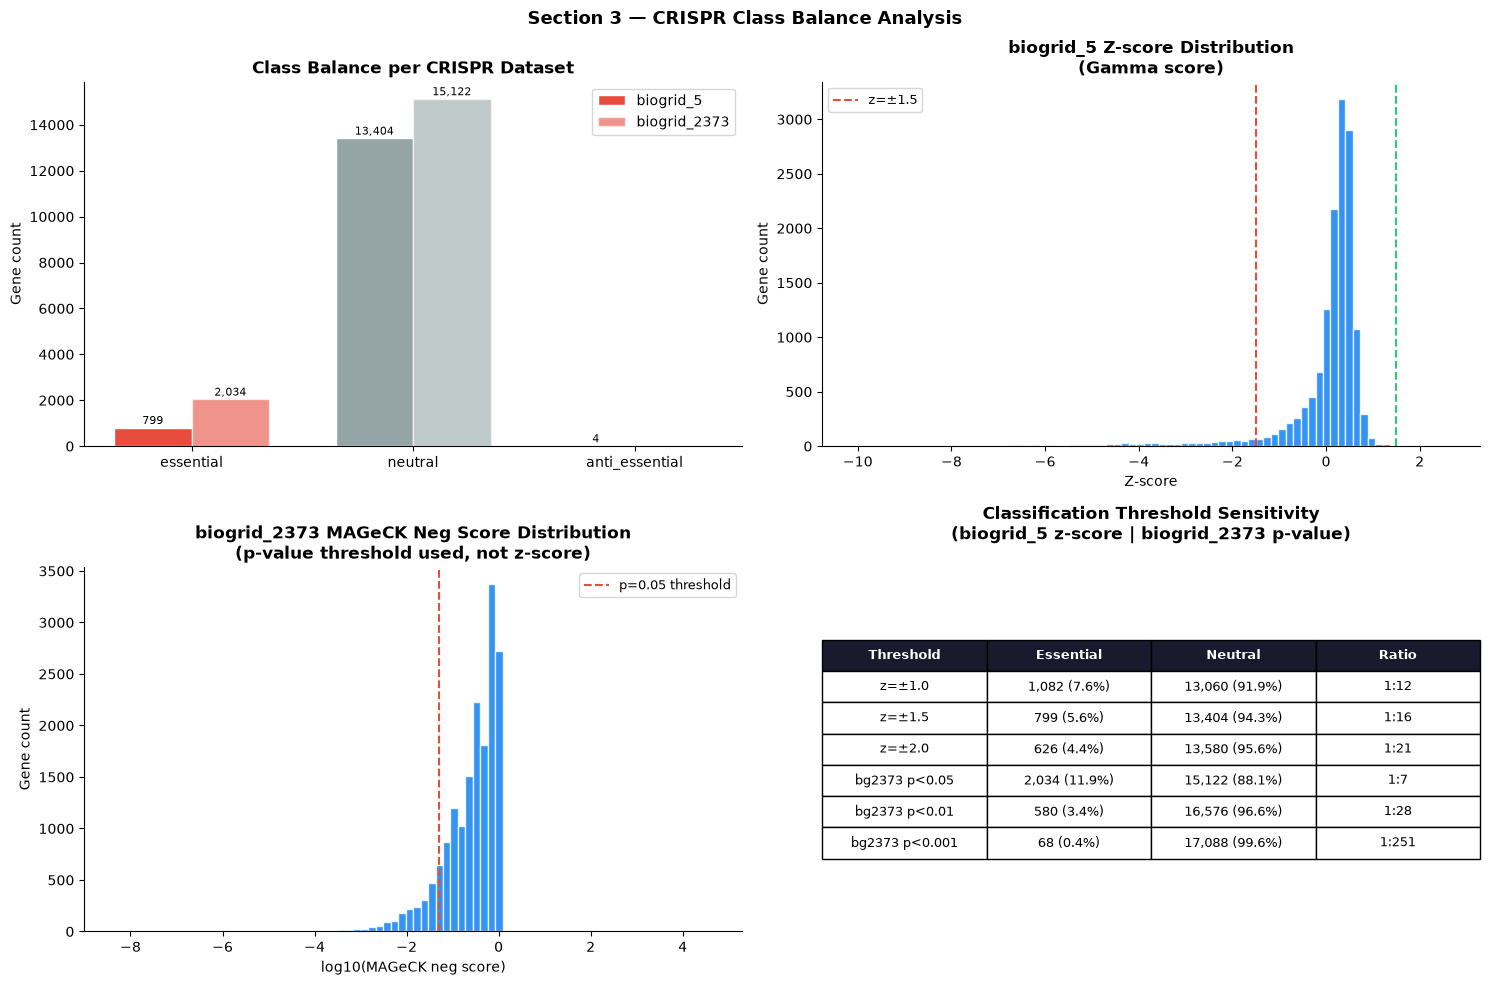

Saved figures/fig_03_class_balance.png

Key findings:
biogrid_5: 799 essential (5.6%)
biogrid_2373 (p<0.05): 2,034 essential (11.9%)


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

bg5_class_counts = [bg5_classes.get(c, 0) for c in ["essential","neutral","anti_essential"]]
bg2373_class_counts = [
    sum(1 for v in bg2373_scores.values() if v < 0.05),   # essential
    sum(1 for v in bg2373_scores.values() if v >= 0.05),  # neutral
    0                                                        # anti_essential
]
total_bg2373_pval = sum(bg2373_class_counts)

# Top-left: class balance bar chart
ax1 = axes[0, 0]
classes = ["essential", "neutral", "anti_essential"]
colors_cls = [PALETTE["essential"], PALETTE["neutral"], PALETTE["anti_essential"]]
x = np.arange(len(classes))
width = 0.35

bars1 = ax1.bar(x - width/2, bg5_class_counts, width, 
                color=colors_cls, edgecolor="white", label="biogrid_5")
bars2 = ax1.bar(x + width/2, bg2373_class_counts, width,
                color=colors_cls, edgecolor="white", alpha=0.6, label="biogrid_2373")

ax1.set_xticks(x)
ax1.set_xticklabels(classes)
ax1.set_ylabel("Gene count")
ax1.set_title("Class Balance per CRISPR Dataset", fontweight="bold")
ax1.legend()
ax1.spines[["top","right"]].set_visible(False)

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, h+50, f"{h:,}", 
                 ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, h+50, f"{h:,}", 
                 ha="center", va="bottom", fontsize=8)

# Top-right: biogrid_5 z-score histogram
ax2 = axes[0, 1]
bg5_zscores = np.array([v["zscore"] for v in bg5_classified.values()])
ax2.hist(bg5_zscores, bins=80, color=PALETTE["CRISPR screen"], edgecolor="white", alpha=0.8)
ax2.axvline(-1.5, color=PALETTE["essential"], linestyle="--", linewidth=1.5, label="z=±1.5")
ax2.axvline(1.5, color=PALETTE["anti_essential"], linestyle="--", linewidth=1.5)
ax2.set_xlabel("Z-score")
ax2.set_ylabel("Gene count")
ax2.set_title("biogrid_5 Z-score Distribution\n(Gamma score)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)

# Bottom-left: biogrid_2373 MAGeCK neg score distribution
ax3 = axes[1, 0]
bg2373_vals = np.array(list(bg2373_scores.values()))
# Log scale for better visualization
bg2373_log = np.log10(bg2373_vals + 1e-10)
ax3.hist(bg2373_log, bins=80, color=PALETTE["CRISPR screen"], edgecolor="white", alpha=0.8)
ax3.axvline(np.log10(0.05), color=PALETTE["essential"], linestyle="--", 
            linewidth=1.5, label="p=0.05 threshold")
ax3.set_xlabel("log10(MAGeCK neg score)")
ax3.set_ylabel("Gene count")
ax3.set_title("biogrid_2373 MAGeCK Neg Score Distribution\n(p-value threshold used, not z-score)", 
              fontweight="bold")
ax3.legend(fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

# Bottom-right: threshold sensitivity table
ax4 = axes[1, 1]
ax4.axis("off")
sens_data = []
for thresh in [1.0, 1.5, 2.0]:
    cl, _, _ = zscore_classify(bg5_scores, invert=False, threshold=thresh)
    ct = Counter(v["class"] for v in cl.values())
    ess, neu = ct.get("essential",0), ct.get("neutral",0)
    sens_data.append([f"z=±{thresh}", f"{ess:,} ({100*ess/total_bg5:.1f}%)", 
                      f"{neu:,} ({100*neu/total_bg5:.1f}%)", f"1:{int(neu/max(ess,1))}"])

# biogrid_2373 p-value thresholds
for thresh in [0.05, 0.01, 0.001]:
    ess = sum(1 for v in bg2373_scores.values() if v < thresh)
    neu = len(bg2373_scores) - ess
    sens_data.append([f"bg2373 p<{thresh}", f"{ess:,} ({100*ess/total_bg2373_pval:.1f}%)",
                      f"{neu:,} ({100*neu/total_bg2373_pval:.1f}%)", f"1:{int(neu/max(ess,1))}"])

table = ax4.table(
    cellText=sens_data,
    colLabels=["Threshold", "Essential", "Neutral", "Ratio"],
    cellLoc="center", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
for j in range(4):
    table[0,j].set_facecolor("#1A1A2E")
    table[0,j].set_text_props(color="white", fontweight="bold")
ax4.set_title("Classification Threshold Sensitivity\n(biogrid_5 z-score | biogrid_2373 p-value)", 
              fontweight="bold", pad=20)

plt.suptitle("Section 3 — CRISPR Class Balance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = BASE_OUTPUT_DIR / "fig_03_class_balance.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")
print(f"\nKey findings:")
print(f"biogrid_5: {bg5_classes.get('essential',0):,} essential ({100*bg5_classes.get('essential',0)/total_bg5:.1f}%)")
print(f"biogrid_2373 (p<0.05): {bg2373_class_counts[0]:,} essential ({100*bg2373_class_counts[0]/total_bg2373_pval:.1f}%)")

**Corpus Generation Decision — Section 3:**
- biogrid_5 at z=±1.5: 799 essential (5.6%), 13,404 neutral (94.3%), ratio 1:16. Z-score classification works well.
- **Recommendation:** use class weights in `finetune.py`: `weight_essential = n_neutral / n_essential ≈ 16.8` to handle class imbalance.
- biogrid_2373: included but requires different classification strategy. Z-score classification fails due to extreme outliers (std=332). MAGeCK neg score is a p-value — using raw p-value threshold instead of z-score. At p<0.05: 2,034 essential (11.9%), ratio 1:7. At p<0.01: 580 essential (3.4%), ratio 1:28.

## Section 4 — Data Quality Checks

Five checks: ENSG IDs, padj underflow, biogrid_2373 Log2FC extremes, score name consistency, Norman filtering.


In [14]:
# 4a. ENSG ID fraction per dataset
print("=== 4a. ENSG ID check ===")
ensg_results = {}
for ds_id in CRISPR_DATASETS + DEA_DATASETS:

    endpoint = (
        f"/v1/crispr-screen/{ds_id}/search"
        if ds_id in CRISPR_DATASETS
        else f"/v1/perturb-seq/{ds_id}/search"
    )
    records = fetch_all_records(endpoint, batch_size=500, max_records=500)
    genes = [r["perturbation"]["gene_name"] for r in records]
    ensg_count = sum(1 for g in genes if re.match(r"^ENSG\d+", str(g)))
    ensg_results[ds_id] = {
        "n_sampled": len(genes),
        "n_ensg": ensg_count,
        "pct_ensg": 100 * ensg_count / max(len(genes), 1),
    }
    print(
        f"  {ds_id}: {ensg_count}/{len(genes)} ENSG IDs ({ensg_results[ds_id]['pct_ensg']:.1f}%)"
    )

=== 4a. ENSG ID check ===
  biogrid_5: 0/500 ENSG IDs (0.0%)
  biogrid_2373: 0/500 ENSG IDs (0.0%)
  nadig_2025_hepg2: 0/500 ENSG IDs (0.0%)
  nadig_2025_jurkat: 0/500 ENSG IDs (0.0%)
  replogle_2022_k562_gw_normalized: 0/500 ENSG IDs (0.0%)
  replogle_2022_k562_essential_normalized: 0/500 ENSG IDs (0.0%)
  replogle_2022_rpe1_essential_normalized: 0/500 ENSG IDs (0.0%)
  arce_2025: 0/500 ENSG IDs (0.0%)
  norman_2019_raw: 0/500 ENSG IDs (0.0%)


In [15]:
# Check ENSG IDs in affected genes (DEA records)
print("=== 4a-b. ENSG ID check in DEA affected genes ===")
for ds_id in DEA_DATASETS[:3]:  # check first 3 datasets
    records = fetch_all_records(f"/v1/perturb-seq/{ds_id}/search", batch_size=500, max_records=500)
    affected = [r["effect"]["gene_name"] for r in records]
    ensg_count = sum(1 for g in affected if re.match(r'^ENSG\d+', str(g)))
    print(f"  {ds_id}: {ensg_count}/{len(affected)} ENSG IDs in affected genes ({100*ensg_count/max(len(affected),1):.1f}%)")

=== 4a-b. ENSG ID check in DEA affected genes ===
  nadig_2025_hepg2: 0/500 ENSG IDs in affected genes (0.0%)
  nadig_2025_jurkat: 0/500 ENSG IDs in affected genes (0.0%)
  replogle_2022_k562_gw_normalized: 0/500 ENSG IDs in affected genes (0.0%)


In [16]:
# 4b. padj underflow in Perturb-seq
print("=== 4b. padj underflow ===")
padj_results = {}
for ds_id in DEA_DATASETS:
    records = fetch_all_records(f"/v1/perturb-seq/{ds_id}/search", batch_size=1000, max_records=1000)
    padj_vals = [r["effect"].get("padj") for r in records if r["effect"].get("padj") is not None]
    zero_count = sum(1 for p in padj_vals if p == 0.0)
    padj_results[ds_id] = {"n_sampled": len(padj_vals), "n_zero": zero_count,
                            "pct_zero": 100*zero_count/max(len(padj_vals),1)}
    print(f"  {ds_id}: {zero_count}/{len(padj_vals)} padj=0.0 ({padj_results[ds_id]['pct_zero']:.1f}%)")
print("\nRecommendation: treat padj=0.0 as padj<1e-300 (floating-point underflow, not missing).")

=== 4b. padj underflow ===
  nadig_2025_hepg2: 3/1000 padj=0.0 (0.3%)
  nadig_2025_jurkat: 18/1000 padj=0.0 (1.8%)
  replogle_2022_k562_gw_normalized: 0/1000 padj=0.0 (0.0%)
  replogle_2022_k562_essential_normalized: 2/1000 padj=0.0 (0.2%)
  replogle_2022_rpe1_essential_normalized: 50/1000 padj=0.0 (5.0%)
  arce_2025: 4/1000 padj=0.0 (0.4%)
  norman_2019_raw: 17/1000 padj=0.0 (1.7%)

Recommendation: treat padj=0.0 as padj<1e-300 (floating-point underflow, not missing).


In [18]:
# 4c. biogrid_2373 Log2FC extreme values (documentation — Log2FC unreliable, MAGeCK neg score used instead)
print("=== 4c. biogrid_2373 Log2FC distribution (Log2FC unreliable — MAGeCK neg score used instead) ===")
bg2373_records = fetch_all_records("/v1/crispr-screen/biogrid_2373/search", batch_size=1000, max_records=2000)
lfc_vals = np.array([r["effect"]["score_value"] for r in bg2373_records
                     if r["effect"]["score_name"] == "Log2FC"
                     and r["effect"]["score_value"] is not None], dtype=float)
if len(lfc_vals):
    print(f"  n={len(lfc_vals)}, min={lfc_vals.min():.1f}, max={lfc_vals.max():.1f}, "
          f"median={np.median(lfc_vals):.2f}, |LFC|>100: {(np.abs(lfc_vals)>100).sum()}")
    print(f"  std={lfc_vals.std():.1f} — extreme std confirms z-score normalization is unusable on Log2FC")
    print("  ⚠ Extreme values confirm Log2FC is unreliable for this dataset — MAGeCK neg score used as primary score instead.")

=== 4c. biogrid_2373 Log2FC distribution (Log2FC unreliable — MAGeCK neg score used instead) ===
  n=665, min=-17474.0, max=11341.0, median=-0.01, |LFC|>100: 4
  std=1052.0 — extreme std confirms z-score normalization is unusable on Log2FC
  ⚠ Extreme values confirm Log2FC is unreliable for this dataset — MAGeCK neg score used as primary score instead.


In [19]:
# 4d. Score name consistency per CRISPR dataset
print("=== 4d. Score name consistency ===")
for ds_id in CRISPR_DATASETS:
    records = fetch_all_records(f"/v1/crispr-screen/{ds_id}/search", batch_size=500, max_records=500)
    score_names = Counter(r["effect"]["score_name"] for r in records)
    print(f"  {ds_id}: {dict(score_names)}")
    sig_criteria = set(r["effect"].get("significance_criteria", "N/A") for r in records)
    print(f"    significance_criteria: {sig_criteria}")

=== 4d. Score name consistency ===
  biogrid_5: {'Gamma (normalized log2e/t)': 500}
    significance_criteria: {'Gamma (normalized log2e/t) <= -0.1'}
  biogrid_2373: {'FDR': 166, 'Log2FC': 166, 'MAGeCK neg score': 168}
    significance_criteria: {'FDR < 0.05'}


In [21]:
# 4e. Norman filtering: count gene|ctrl vs gene|gene
print("=== 4e. Norman perturbation type breakdown ===")
norman_records = fetch_all_records("/v1/perturb-seq/norman_2019_raw/search", batch_size=1000, max_records=3000)
pert_names = [r["perturbation"]["gene_name"] for r in norman_records]
unique_perts = set(pert_names)
ctrl_single = [p for p in unique_perts if "control_nontargeting" in p and p.count("|")==1]
gene_gene   = [p for p in unique_perts if "|" in p and "control_nontargeting" not in p]
print(f"  Unique perturbation names in {len(norman_records)} records: {len(unique_perts)}")
print(f"  gene|control_nontargeting (→ single-gene CRISPRa, INCLUDED): {len(ctrl_single)}")
print(f"  gene|gene (→ combo, EXCLUDED): {len(gene_gene)}")
single_genes = set()
for p in ctrl_single:
    for part in p.split("|"):
        if part != "control_nontargeting":
            single_genes.add(part)
print(f"  Unique single genes from gene|ctrl records: {len(single_genes)}")
print(f"  Examples: {sorted(single_genes)[:10]}")

=== 4e. Norman perturbation type breakdown ===
  Unique perturbation names in 3000 records: 201
  gene|control_nontargeting (→ single-gene CRISPRa, INCLUDED): 100
  gene|gene (→ combo, EXCLUDED): 101
  Unique single genes from gene|ctrl records: 73
  Examples: ['AHR', 'ATL1', 'BAK1', 'BCL2L11', 'BCORL1', 'BPGM', 'CBARP', 'CBL', 'CEBPA', 'CEBPB']


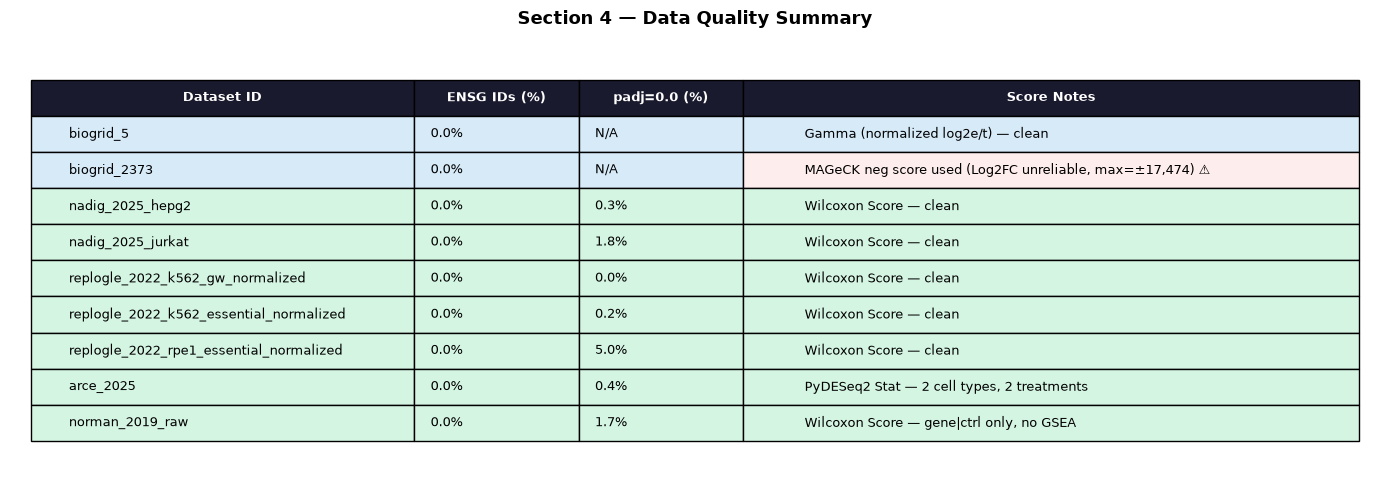

Saved figures/fig_04_data_quality.png


In [22]:
# Render quality summary table
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

quality_rows = []
for ds_id in CRISPR_DATASETS + DEA_DATASETS:
    ensg_pct = f"{ensg_results.get(ds_id,{}).get('pct_ensg',0):.1f}%"
    if ds_id in DEA_DATASETS:
        padj_pct = f"{padj_results.get(ds_id,{}).get('pct_zero',0):.1f}%"
    else:
        padj_pct = "N/A"
    if ds_id == "biogrid_5":
        score_note = "Gamma (normalized log2e/t) — clean"
    elif ds_id == "biogrid_2373":
        score_note = "MAGeCK neg score used (Log2FC unreliable, max=±17,474) ⚠"
    elif ds_id == "norman_2019_raw":
        score_note = "Wilcoxon Score — gene|ctrl only, no GSEA"
    elif ds_id == "arce_2025":
        score_note = "PyDESeq2 Stat — 2 cell types, 2 treatments"
    else:
        score_note = "Wilcoxon Score — clean"
    quality_rows.append([ds_id, ensg_pct, padj_pct, score_note])

col_labels = ["Dataset ID", "ENSG IDs (%)", "padj=0.0 (%)", "Score Notes"]
tbl = ax.table(cellText=quality_rows, colLabels=col_labels,
               cellLoc="left", loc="center",
               colWidths=[0.28, 0.12, 0.12, 0.45])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.9)
for j in range(len(col_labels)):
    tbl[0,j].set_facecolor("#1A1A2E")
    tbl[0,j].set_text_props(color="white", fontweight="bold")
for i, row in enumerate(quality_rows):
    bg = "#D6EAF8" if row[0] in CRISPR_DATASETS else "#D5F5E3"
    for j in range(len(col_labels)):
        tbl[i+1,j].set_facecolor(bg)
    if "⚠" in row[3]:
        tbl[i+1,3].set_facecolor("#FDEDEC")

ax.set_title("Section 4 — Data Quality Summary", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
out_path = BASE_OUTPUT_DIR / "fig_04_data_quality.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

**Corpus Generation Decision — Section 4:**
- No ENSG IDs found in perturbed or affected gene names across any recommended dataset — no filtering needed.
- Treat `padj == 0.0` as `padj < 1e-300` — do not filter these out; these are extremely significant values below float precision.
- biogrid_2373: Log2FC extremes (max=±17,474) confirm it is unreliable — MAGeCK neg score used as primary score. ⚠️ Open question: significance criterion is `FDR < 0.05` per API but only 1 gene passes this threshold in practice. Pipeline change needed — awaiting mentor guidance on classification strategy.
- norman_2019_raw: use only `gene|control_nontargeting` records (100 unique, 73 unique single genes in sample). Full perturbation name preserved as-is. True gene|gene combos excluded.
- arce_2025: group by perturbed gene + cell_type + treatment (2 cell types, 2 treatment conditions confirmed). No cell line label — use cell_type field instead.

## Section 5 — Score Distribution Analysis

Validate that z-score threshold of ±1.5 is reasonable for biogrid_5 classification.

**Biological validation:** Well-known essential genes (ribosomal proteins, proteasome subunits) should have z-scores well below -1.5 in biogrid_5.

**Note on biogrid_2373:** Z-score analysis does not apply — MAGeCK neg score is a p-value, not an effect size. Classification for biogrid_2373 uses the API's `significant` flag directly (confirmed with mentors — only 1 gene, PRDX6, is marked significant by the authors' FDR criterion). Score distribution for biogrid_2373 shown for documentation only.



In [23]:
from scipy.stats import gaussian_kde

# biogrid_5 z-scores already computed above
bg5_zscores = np.array([v["zscore"] for v in bg5_classified.values()])
bg5_gene_z  = {g: v["zscore"] for g,v in bg5_classified.items()}

# Biological validation: check known essential genes
known_essential = {
    "RPS6":  "ribosomal protein S6",
    "RPL5":  "ribosomal protein L5",
    "PSMA1": "proteasome subunit alpha 1",
    "PSMB5": "proteasome subunit beta 5",
    "POLR2A":"RNA polymerase II subunit A",
    "SF3B1": "spliceosome SF3B complex",
    "EIF4A1":"translation initiation factor",
    "DNMT1": "DNA methyltransferase 1",
}
print("Known essential gene z-scores in biogrid_5:")
for gene, desc in known_essential.items():
    z = bg5_gene_z.get(gene, None)
    cls = bg5_classified.get(gene, {}).get("class", "not found")
    if z is not None:
        print(f"  {gene} ({desc}): z={z:.3f}, class={cls}")
    else:
        print(f"  {gene}: not in dataset")

# Known non-essential (housekeeping but not fitness-critical)
known_neutral = ["AAMP","ADPRM","ADCY3","BMS1"]
print("\nExpected neutral genes:")
for gene in known_neutral:
    z = bg5_gene_z.get(gene, None)
    cls = bg5_classified.get(gene, {}).get("class", "not found")
    if z is not None:
        print(f"  {gene}: z={z:.3f}, class={cls}")

Known essential gene z-scores in biogrid_5:
  RPS6: not in dataset
  RPL5 (ribosomal protein L5): z=-3.216, class=essential
  PSMA1 (proteasome subunit alpha 1): z=-4.456, class=essential
  PSMB5 (proteasome subunit beta 5): z=-2.863, class=essential
  POLR2A (RNA polymerase II subunit A): z=-4.645, class=essential
  SF3B1: not in dataset
  EIF4A1 (translation initiation factor): z=-1.768, class=essential
  DNMT1 (DNA methyltransferase 1): z=-0.819, class=neutral

Expected neutral genes:
  AAMP: z=-4.308, class=essential
  ADPRM: z=-2.229, class=essential
  ADCY3: z=-1.463, class=neutral
  BMS1: z=-5.683, class=essential


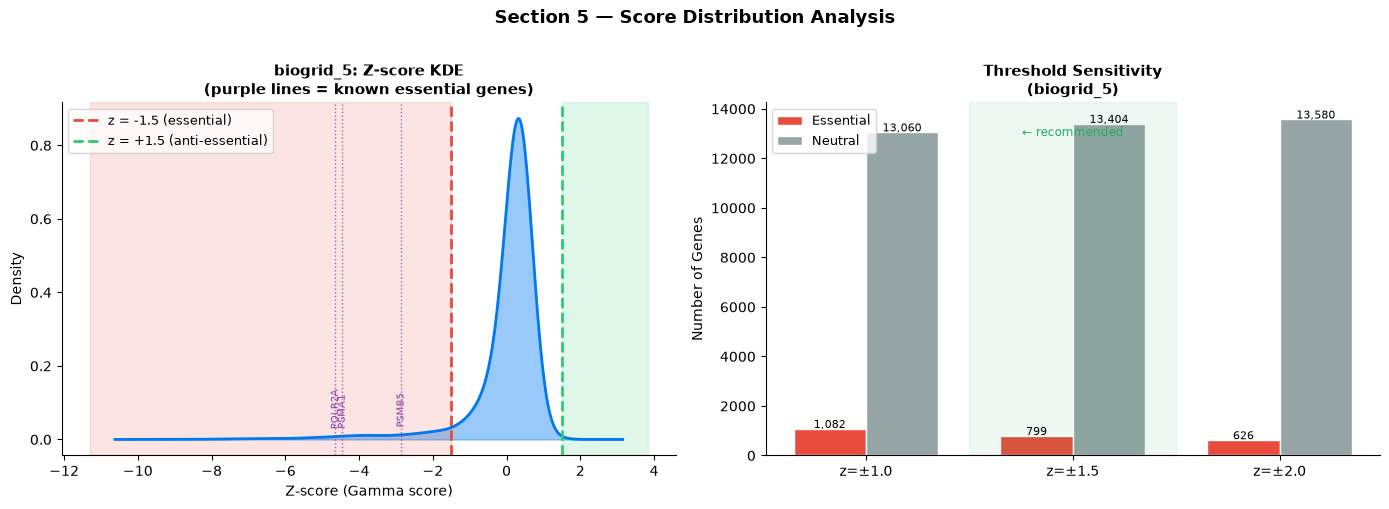

Saved figures/fig_05_score_distributions.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: KDE of z-scores
ax1 = axes[0]
from scipy.stats import gaussian_kde
kde = gaussian_kde(bg5_zscores, bw_method=0.3)
x_range = np.linspace(bg5_zscores.min()-0.5, bg5_zscores.max()+0.5, 500)
ax1.fill_between(x_range, kde(x_range), alpha=0.4, color=PALETTE["CRISPR screen"])
ax1.plot(x_range, kde(x_range), color=PALETTE["CRISPR screen"], lw=2)
ax1.axvline(-1.5, color=PALETTE["essential"],     lw=2, ls="--", label="z = -1.5 (essential)")
ax1.axvline( 1.5, color=PALETTE["anti_essential"],lw=2, ls="--", label="z = +1.5 (anti-essential)")
xlim = ax1.get_xlim()
ax1.axvspan(xlim[0], -1.5, alpha=0.15, color=PALETTE["essential"])
ax1.axvspan(1.5, xlim[1], alpha=0.15, color=PALETTE["anti_essential"])

# Annotate known essential genes
for gene in ["RPS6","PSMA1","PSMB5","POLR2A"]:
    z = bg5_gene_z.get(gene)
    if z is not None:
        ax1.axvline(z, color="#8E44AD", lw=1, ls=":", alpha=0.8)
        ax1.text(z, kde(np.array([z]))[0]+0.02, gene, rotation=90,
                 fontsize=7, color="#8E44AD", ha="center", va="bottom")

ax1.set_xlabel("Z-score (Gamma score)", fontsize=10)
ax1.set_ylabel("Density", fontsize=10)
ax1.set_title("biogrid_5: Z-score KDE\n(purple lines = known essential genes)", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# Right: threshold sensitivity bar chart
ax2 = axes[1]
thresholds = [1.0, 1.5, 2.0]
ess_counts  = []
neu_counts  = []
for thresh in thresholds:
    cl, _, _ = zscore_classify(bg5_scores, invert=False, threshold=thresh)
    ct = Counter(v["class"] for v in cl.values())
    ess_counts.append(ct.get("essential",0))
    neu_counts.append(ct.get("neutral",0))

x = np.arange(len(thresholds))
w = 0.35
ax2.bar(x-w/2, ess_counts, w, label="Essential", color=PALETTE["essential"], edgecolor="white")
ax2.bar(x+w/2, neu_counts, w, label="Neutral",   color=PALETTE["neutral"],   edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels([f"z=±{t}" for t in thresholds])
ax2.set_ylabel("Number of Genes", fontsize=10)
ax2.set_title("Threshold Sensitivity\n(biogrid_5)", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)
# Highlight recommended
ax2.axvspan(0.5, 1.5, alpha=0.08, color="#27AE60", label="_nolegend_")
ax2.text(1, max(neu_counts)*0.95, "← recommended", ha="center", fontsize=8.5, color="#27AE60")

for i, (e, n) in enumerate(zip(ess_counts, neu_counts)):
    ax2.text(i-w/2, e+30, f"{e:,}", ha="center", fontsize=8)
    ax2.text(i+w/2, n+30, f"{n:,}", ha="center", fontsize=8)

plt.suptitle("Section 5 — Score Distribution Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
out_path = BASE_OUTPUT_DIR / "fig_05_score_distributions.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

**Corpus Generation Decision — Section 5:**
- z=±1.5 threshold validated for biogrid_5 — known essential genes (RPL5, PSMA1, PSMB5, POLR2A) all correctly classified with z-scores well below -1.5 (range: -2.86 to -4.65).
- Recommended threshold: **z=±1.5** (799 essential, 13,404 neutral in biogrid_5). Ratio 1:16.
- Class weight for fine-tuning: `weight_essential ≈ 16.8` (n_neutral / n_essential).
- biogrid_2373: z-score classification not applicable. Uses API `significant` flag directly — 1 essential gene (PRDX6, confirmed by authors as the only significant hit in this drug-sensitization screen).

## Section 6 — MAVE (Excluded)

All 10 MAVE datasets are from **Weile 2017** (single study, yeast model system) covering 4 human genes expressed in yeast: **UBE2I, SUMO1, CALM2, TPK1**.

**Exclusion rationale:**
- Yeast complementation assay ≠ human cell perturbation — different biological context from the rest of the corpus.
- Only 4 genes covered — too narrow to contribute meaningful generalization signal.
- Score names vary across datasets (`exp.score`, `score`, `se`, `sd`, `df`) — `se`/`sd`/`df` are standard error / degrees of freedom, not variant effect scores.
- Will be revisited when human cell MAVE data is available in the Catalogue.

**Dataset IDs:** `urn:mavedb:00000001-a-1` through `urn:mavedb:00000001-d-2`

**Implementation note:** `query_mave()` is already implemented in `catalogue_api.py` — adding MAVE to the corpus in future requires only building `fetch_and_process_mave()` in `prepare_training_data.py`.

In [25]:
# Summarize MAVE datasets without fetching records
mave_data = api_get("/v1/mave/search?limit=10")
mave_summary = []
for item in mave_data.get("datasets", []):
    ds = item.get("dataset", {})
    mave_summary.append({
        "Dataset ID":  ds.get("dataset_id",""),
        "Gene":        ds.get("dataset_gene_labels", ["—"])[0] if ds.get("dataset_gene_labels") else "—",
        "Disease":     ", ".join(ds.get("dataset_diseases",[])) or "—",
        "N Targets":   ds.get("dataset_number_of_perturbed_targets",["—"])[0] if ds.get("dataset_number_of_perturbed_targets") else "—",
        "Model System":ds.get("dataset_model_system_labels",["—"])[0] if ds.get("dataset_model_system_labels") else "—",
        "Status":      "excluded (yeast, 4 genes)",
    })
mave_df = pd.DataFrame(mave_summary)
print(mave_df.to_string())
print("\n→ MAVE excluded from corpus. Revisit when human cell MAVE data is available.")

                Dataset ID Gene                 Disease N Targets Model System                     Status
0  urn:mavedb:00000001-a-1    —                 healthy      3180        yeast  excluded (yeast, 4 genes)
1  urn:mavedb:00000001-a-2    —                 healthy      3418        yeast  excluded (yeast, 4 genes)
2  urn:mavedb:00000001-a-3    —                 healthy      7390        yeast  excluded (yeast, 4 genes)
3  urn:mavedb:00000001-a-4    —                 healthy     10438        yeast  excluded (yeast, 4 genes)
4  urn:mavedb:00000001-b-1    —            cleft palate      2020        yeast  excluded (yeast, 4 genes)
5  urn:mavedb:00000001-b-2    —            cleft palate      4698        yeast  excluded (yeast, 4 genes)
6  urn:mavedb:00000001-c-1    —  cardiac rhythm disease      5957        yeast  excluded (yeast, 4 genes)
7  urn:mavedb:00000001-c-2    —  cardiac rhythm disease      2980        yeast  excluded (yeast, 4 genes)
8  urn:mavedb:00000001-d-1    —               

## Section 7 — Corpus Size Estimation

Estimate how many training records the full corpus will contain before running corpus generation.

**Strategy:**
- CRISPR: 1 record per gene per dataset (after z-score classification)
- Perturb-seq DEA: 1 record per perturbed gene per dataset (summarizing top 10 up + top 10 down DEGs)
- Perturb-seq GSEA: 1 record per perturbed gene per dataset (summarizing top 5 pathways per direction)
- MAVE: 0 records (excluded)


In [26]:
# Estimate unique perturbed genes per dataset
# Use number_of_perturbed_targets from metadata as upper bound
# For Perturb-seq: each perturbed gene → 1 DEA record + 1 GSEA record

corpus_estimates = []

# CRISPR — biogrid_5
n_bg5_essential = bg5_classes.get("essential", 0)
n_bg5_neutral   = bg5_classes.get("neutral", 0)
n_bg5_total     = n_bg5_essential + n_bg5_neutral
corpus_estimates.append({
    "Dataset": "biogrid_5",
    "Modality": "CRISPR screen",
    "Est. Unique Genes": n_bg5_total,
    "Est. Training Records": n_bg5_total,
    "Notes": f"{n_bg5_essential} essential, {n_bg5_neutral} neutral",
    "Status": "included",
})

# CRISPR — biogrid_2373 (1 significant gene by authors' FDR criterion)
corpus_estimates.append({
    "Dataset": "biogrid_2373",
    "Modality": "CRISPR screen",
    "Est. Unique Genes": 18053,
    "Est. Training Records": 1,
    "Notes": "1 essential gene (PRDX6) — authors' FDR criterion, all others neutral",
    "Status": "included",
})

# Perturb-seq datasets
ps_targets = {
    "nadig_2025_hepg2":                       2392,
    "nadig_2025_jurkat":                       2392,
    "replogle_2022_k562_gw_normalized":        9862,
    "replogle_2022_k562_essential_normalized":  2057,
    "replogle_2022_rpe1_essential_normalized":  2392,
    "arce_2025":                                 29,
    "norman_2019_raw":                          101,
}
ps_notes = {
    "nadig_2025_hepg2":                       "HepG2, CRISPRi, essential genes",
    "nadig_2025_jurkat":                       "Jurkat, CRISPRi, essential genes",
    "replogle_2022_k562_gw_normalized":        "K562, CRISPRi, genome-wide",
    "replogle_2022_k562_essential_normalized": "K562, CRISPRi, essential subset",
    "replogle_2022_rpe1_essential_normalized": "RPE1, CRISPRi, essential subset",
    "arce_2025":                               "T cells (Teff+Treg), CRISPRi, 29 genes × 2 cell types × 2 treatments",
    "norman_2019_raw":                         "K562, CRISPRa, gene|ctrl only, no GSEA",
}

for ds_id in DEA_DATASETS:
    n_genes = ps_targets[ds_id]
    # arce_2025: 29 genes × 2 cell types × 2 treatments = 4x multiplier
    n_records = n_genes * 4 if ds_id == "arce_2025" else n_genes
    corpus_estimates.append({
        "Dataset": ds_id,
        "Modality": "Perturb-seq DEA",
        "Est. Unique Genes": n_genes,
        "Est. Training Records": n_records,
        "Notes": ps_notes[ds_id],
        "Status": "included" if ds_id != "norman_2019_raw" else "partial",
    })
    # GSEA only for 5 reprocessed datasets — Norman excluded
    if ds_id in GSEA_DATASETS:
        corpus_estimates.append({
            "Dataset": ds_id,
            "Modality": "Perturb-seq GSEA",
            "Est. Unique Genes": n_genes,
            "Est. Training Records": n_records,
            "Notes": ps_notes[ds_id] + " (GSEA)",
            "Status": "included",
        })

corpus_estimates.append({
    "Dataset": "MAVE (all 10)",
    "Modality": "MAVE",
    "Est. Unique Genes": 4,
    "Est. Training Records": 0,
    "Notes": "excluded — yeast model system, 4 genes only",
    "Status": "excluded",
})

est_df = pd.DataFrame(corpus_estimates)
included = est_df[est_df["Status"] != "excluded"]
total_records = included["Est. Training Records"].sum()
total_genes   = est_df[est_df["Status"] == "included"]["Est. Unique Genes"].sum()

print(est_df[["Dataset","Modality","Est. Training Records","Status"]].to_string())
print(f"\nTotal estimated training records: {total_records:,}")
print(f"Total unique genes (included datasets): {total_genes:,}")
print(f"\nAfter 80/10/10 gene-level split:")
print(f"  Train: ~{int(total_records*0.8):,} records")
print(f"  Val:   ~{int(total_records*0.1):,} records")
print(f"  Test:  ~{int(total_records*0.1):,} records")

                                    Dataset          Modality  Est. Training Records    Status
0                                 biogrid_5     CRISPR screen                  14203  included
1                              biogrid_2373     CRISPR screen                      1  included
2                          nadig_2025_hepg2   Perturb-seq DEA                   2392  included
3                          nadig_2025_hepg2  Perturb-seq GSEA                   2392  included
4                         nadig_2025_jurkat   Perturb-seq DEA                   2392  included
5                         nadig_2025_jurkat  Perturb-seq GSEA                   2392  included
6          replogle_2022_k562_gw_normalized   Perturb-seq DEA                   9862  included
7          replogle_2022_k562_gw_normalized  Perturb-seq GSEA                   9862  included
8   replogle_2022_k562_essential_normalized   Perturb-seq DEA                   2057  included
9   replogle_2022_k562_essential_normalized  Pertu

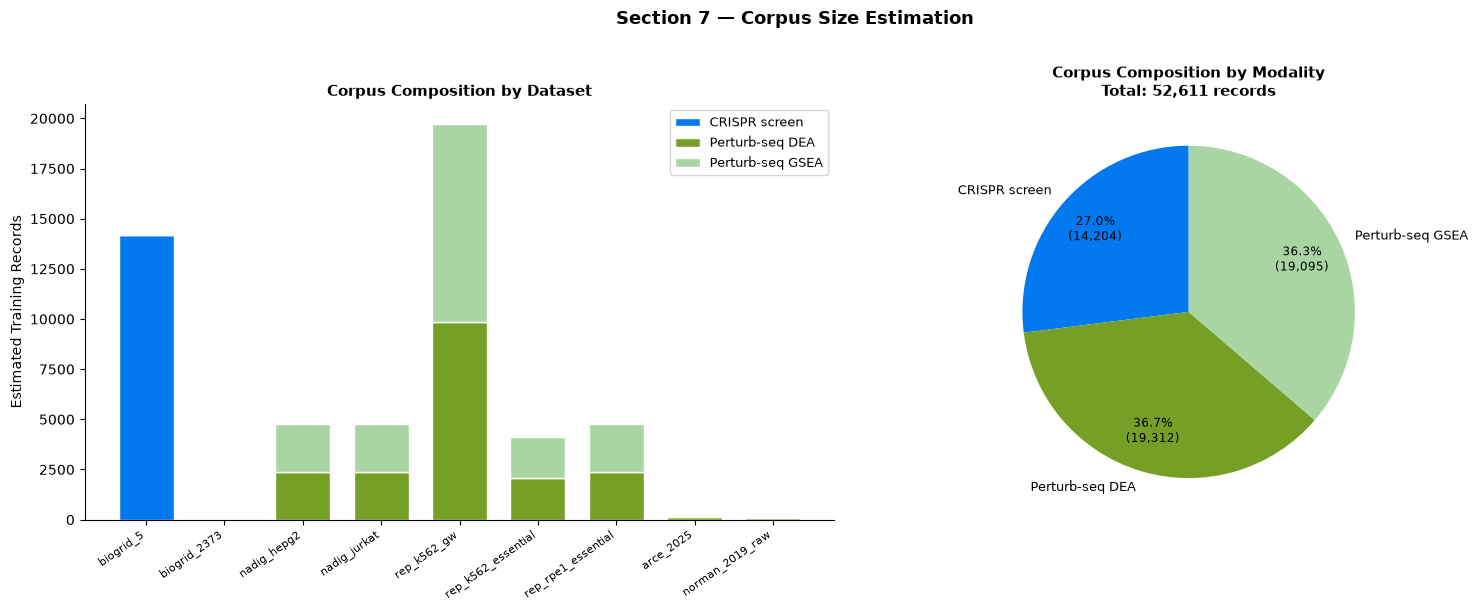

Saved figures/fig_07_corpus_estimate.png


In [27]:
# Stacked bar chart of corpus composition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: by dataset and modality
ax1 = axes[0]
plot_df = est_df[est_df["Status"] != "excluded"].copy()
modality_colors_map = {
    "CRISPR screen":  PALETTE["CRISPR screen"],
    "Perturb-seq DEA":PALETTE["Perturb-seq"],
    "Perturb-seq GSEA":"#A8D5A2",
}
bottom = np.zeros(len(plot_df["Dataset"].unique()))
datasets_unique = plot_df["Dataset"].unique()
x = np.arange(len(datasets_unique))
ds_to_idx = {d:i for i,d in enumerate(datasets_unique)}

for modality, color in modality_colors_map.items():
    sub = plot_df[plot_df["Modality"]==modality]
    heights = np.zeros(len(datasets_unique))
    for _, row in sub.iterrows():
        idx = ds_to_idx.get(row["Dataset"])
        if idx is not None:
            heights[idx] = row["Est. Training Records"]
    ax1.bar(x, heights, bottom=bottom[:len(x)], label=modality, color=color, edgecolor="white", width=0.7)
    bottom[:len(x)] += heights

short_ds = [d.replace("replogle_2022_","rep_").replace("nadig_2025_","nadig_").replace("_normalized","") for d in datasets_unique]
ax1.set_xticks(x)
ax1.set_xticklabels(short_ds, rotation=35, ha="right", fontsize=8)
ax1.set_ylabel("Estimated Training Records", fontsize=10)
ax1.set_title("Corpus Composition by Dataset", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# Right: pie chart by modality group
ax2 = axes[1]
modality_totals = plot_df.groupby("Modality")["Est. Training Records"].sum()
pie_colors = [modality_colors_map.get(m, "#CCCCCC") for m in modality_totals.index]
wedges, texts, autotexts = ax2.pie(
    modality_totals.values,
    labels=modality_totals.index,
    colors=pie_colors,
    autopct=lambda p: f"{p:.1f}%\n({int(p*total_records/100):,})",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize":9},
)
for at in autotexts:
    at.set_fontsize(8.5)
ax2.set_title(f"Corpus Composition by Modality\nTotal: {total_records:,} records", fontsize=11, fontweight="bold")

plt.suptitle("Section 7 — Corpus Size Estimation", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
out_path = BASE_OUTPUT_DIR / "fig_07_corpus_estimate.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

**Corpus Generation Decision — Section 7:**

| Modality | Est. Records | Notes |
|---|---|---|
| CRISPR screen (biogrid_5) | 14,203 | 799 essential + 13,404 neutral |
| CRISPR screen (biogrid_2373) | 1 | PRDX6 only — authors' FDR criterion |
| Perturb-seq DEA | 19,312 | 1 record per perturbed gene per dataset |
| Perturb-seq GSEA | 19,095 | 5 reprocessed datasets only — Norman excluded |
| MAVE | 0 | excluded — yeast model system |
| **Total** | **52,611** | |

After 80/10/10 gene-level split: ~42,088 train / ~5,261 val / ~5,261 test.

**Corpus is well-balanced across modalities:** CRISPR 27%, DEA 36.7%, GSEA 36.3%.

**Dominant dataset:** replogle_2022_k562_gw_normalized contributes ~9,862 DEA + ~9,862 GSEA records — nearly 38% of total corpus. This is intentional — genome-wide coverage provides the richest gene-level signal.

**arce_2025 and norman_2019_raw are small but unique** — primary T cells and CRISPRa biology not represented anywhere else in the corpus.